---
title: Linear Regression In-depth Math Intuition
description: Master the mathematical mechanics of Linear Regression by walking through
  step-by-step calculations of Hypothesis functions, Mean Squared Error (MSE), and
  Gradient Descent parameter optimization.
author: Md Muztahid Hassan
date: '2026-06-19 00:08:46'
toc: true
execute:
  warning: false
  echo: true
order: 15
---


In Machine Learning, we call the X data as input features/ Independent Variables and Y data as output features/ Dependent Variables.

## Simple Linear Regression

We try to calculate the weights and biases of the model to predict the output feature Y. In mathematical terms, the linear equation is:

$$ y = mx + c $$

In machine learning, we will express the equation as:

$$ y = w_0 + w_1x_1 $$

Here:
- $y$ is the output feature
- $x_1$ is the input feature
- $w_1$ is the slope
- $w_0$ is the bias / intercept

This is the equation of simple linear regression. 


## Multiple Linear Regression

The equation of multiple linear regression is:

$$ y = w_0 + w_1x_1 + w_2x_2 + \dots + w_mx_m $$

Here:
- $y$ is the output feature
- $x_1, x_2, \dots, x_m$ are the input features
- $w_1, w_2, \dots, w_m$ are the weights
- $w_0$ is the bias / intercept


In machine learning, we follow the below procedures:

```{mermaid}
%%| echo: false
graph TD
    %% Training Phase
    X_Train[X Train] --> TD[Training Data]
    Y_Train[Y Train] --> TD
    TD --> LA[Learning Algorithm]
    LA --> H[Hypothesis / Model]
    
    %% Prediction Phase
    X_New[X Input] --> H
    H --> Y_Pred["Y prediction (Y-bar)"]
```

## Hypothesis

The hypothesis is an equation of prediction. It comes from straight line formula, $$ y= mx+c $$ 

This is for linear regression. But for other models, the hypothesis is different.

For linear regression, the hypothesis is:

$$ h_\theta(x) = \theta_0 + \theta_1 x $$

### Example: House Price Prediction Dataset

Suppose we have a dataset for predicting house prices based on area, where:
- $X$ is the input feature (Area)
- $Y$ is the output target (Price)

| $X$ (Area) | $Y$ (Price) |
| :---: | :---: |
| 7 | 11 |
| 2 | 4 |
| 17 | 25 |
| 9 | 15 |

We want to find the linear equation (the best fit line) for this dataset:

$$ h_\theta(x) = \theta_0 + \theta_1 x $$

Since we do not know the optimal values of $\theta_0$ and $\theta_1$ initially, we start by assuming initial values:
- Assume $\theta_0 = 1$
- Assume $\theta_1 = 1.5$

Using these parameters, we can calculate the predicted value $h_\theta(x)$ for each row in the dataset:

- **1st row ($x = 7$):**
  $$ h_\theta(7) = 1 + 1.5 \times 7 = 11.5 $$
- **2nd row ($x = 2$):**
  $$ h_\theta(2) = 1 + 1.5 \times 2 = 4.0 $$
- **3rd row ($x = 17$):**
  $$ h_\theta(17) = 1 + 1.5 \times 17 = 26.5 $$
- **4th row ($x = 9$):**
  $$ h_\theta(9) = 1 + 1.5 \times 9 = 14.5 $$

These calculated values are our model's predictions ($\bar{Y}$ or $\hat{y}$).

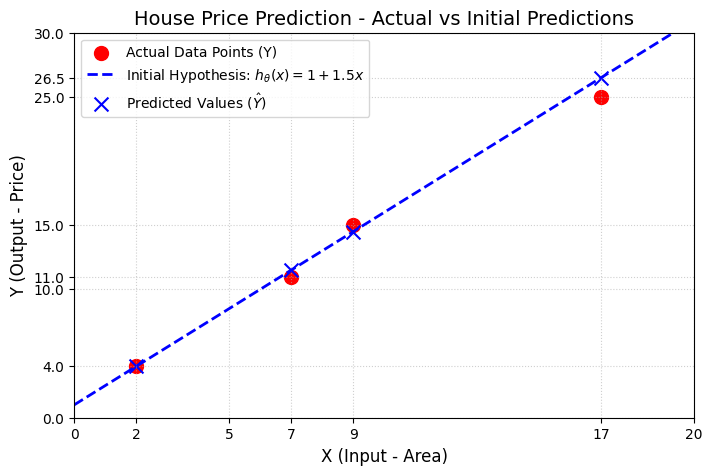

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset points
X = np.array([7, 2, 17, 9])
Y = np.array([11, 4, 25, 15])

# Create plot
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='red', marker='o', s=100, label='Actual Data Points (Y)')

# Assumed line: y = 1.0 + 1.5 * x
x_line = np.linspace(0, 20, 100)
y_line = 1.0 + 1.5 * x_line
plt.plot(x_line, y_line, color='blue', linestyle='--', linewidth=2, label='Initial Hypothesis: $h_\\theta(x) = 1 + 1.5x$')

# Predicted points on the line
Y_pred = 1.0 + 1.5 * X
plt.scatter(X, Y_pred, color='blue', marker='x', s=100, label='Predicted Values ($\\hat{Y}$)')

# Customizing limits and ticks to match the visual sketch
plt.title('House Price Prediction - Actual vs Initial Predictions', fontsize=14)
plt.xlabel('X (Input - Area)', fontsize=12)
plt.ylabel('Y (Output - Price)', fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 30)
plt.xticks([0, 2, 5, 7, 9, 17, 20])
plt.yticks([0, 4, 10, 11, 15, 25, 26.5, 30])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Actual vs. Predicted Values Table

Here is the comparison table displaying the input features, actual target values, and the calculated predicted values:

| $X$ | $Y$ | Predicted |
| :---: | :---: | :---: |
| 7 | 11 | 11.5 |
| 2 | 4 | 4.0 |
| 17 | 25 | 26.5 |
| 9 | 15 | 14.5 |

## Cost Function (Mean Squared Error - MSE)

By comparing the predicted values ($\hat{y}$) and the actual target values ($Y$), we can see that there is some error in our initial predictions. The line from our first iteration does not pass through all the actual data points. To improve the model, we need to adjust the slope ($\theta_1$) and intercept ($\theta_0$) to minimize this error.

To measure how well our model fits the data, we calculate the **loss** and the overall **cost** using the **Mean Squared Error (MSE)** cost function.

### Loss Function (for a single prediction)
$$ \text{Loss} = \left( h_\theta(x) - y \right)^2 $$

### Cost Function Equation (for the entire dataset)
$$ J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

Where:
* $m$ = total number of training examples ($m = 4$ in our dataset)
* $i$ = index of the training example
* $h_\theta(x^{(i)})$ = prediction for the $i$-th example
* $y^{(i)}$ = actual target value for the $i$-th example

---

### Step-by-Step Calculation

Let's calculate the cost $J$ for our current model:

$$ J = \frac{1}{2 \times 4} \left[ (11.5 - 11)^2 + (4 - 4)^2 + (26.5 - 25)^2 + (14.5 - 15)^2 \right] $$

$$ J = \frac{1}{8} \left[ (0.5)^2 + (0)^2 + (1.5)^2 + (-0.5)^2 \right] $$

$$ J = \frac{1}{8} \left[ 0.25 + 0 + 2.25 + 0.25 \right] $$

$$ J = \frac{1}{8} \times 2.75 = 0.34375 $$

The **Mean Squared Error (MSE)** is **$0.34375$**. Our goal in linear regression is to optimize $\theta_0$ and $\theta_1$ using optimization techniques (like Gradient Descent) to reduce this cost as close to zero as possible.

## Gradient Descent Optimization

To reduce the error (cost), we use **Gradient Descent**. It is a cost optimization algorithm used to find the optimal weights and bias by iteratively moving toward the **global minimum** of the cost function. The algorithm automatically converges and stops once the loss reaches its minimal point.

In each iteration, we calculate the gradient of the cost function, update the parameters ($\theta_0$ and $\theta_1$), and run the next iteration with the updated values. We repeat this process until the cost converges to its minimum.

![gradient descent](images/im1.png)

For two-dimensional parameter spaces (like our simple linear regression), the loss surface is shaped like a bowl:

![gradient descent 2D](images/im2.png)

---

### Gradient Descent Equation

The general update rule for any parameter $\theta_j$ is:

$$ \theta_j \leftarrow \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta_0, \theta_1) $$

Where:
* $\theta_j$ represents the weights or bias of the model.
* $\alpha$ is the **learning rate** (typically set to a small value such as $0.01$). It controls the step size toward the minimum.
  * *Note*: If $\alpha$ is too large, the algorithm might overshoot the global minimum and fail to converge.
* $\frac{\partial}{\partial \theta_j} J(\theta_0, \theta_1)$ is the partial derivative of the cost function with respect to $\theta_j$, indicating the direction and magnitude of the steepest ascent.

---

### Deriving the Update Rules

Given our Cost Function:
$$ J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

We compute the partial derivative for each parameter:

#### 1. Derivative with respect to $\theta_0$ (Intercept / Bias)
Since $\frac{\partial}{\partial \theta_0} h_\theta(x) = \frac{\partial}{\partial \theta_0} (\theta_0 + \theta_1 x) = 1$:

$$ \frac{\partial}{\partial \theta_0} J(\theta_0, \theta_1) = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) $$

#### 2. Derivative with respect to $\theta_1$ (Slope / Weight)
Since $\frac{\partial}{\partial \theta_1} h_\theta(x) = \frac{\partial}{\partial \theta_1} (\theta_0 + \theta_1 x) = x$:

$$ \frac{\partial}{\partial \theta_1} J(\theta_0, \theta_1) = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)} $$

---

### Final Gradient Descent Equations for Linear Regression

Substituting the derived gradients into the update rules yields the equations that are calculated simultaneously during each iteration:

$$ \theta_0 \leftarrow \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) $$

$$ \theta_1 \leftarrow \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)} $$

## 1st Iteration of Gradient Descent

Now, let us perform the **1st iteration** of Gradient Descent to update our parameters. We begin by assuming initial values:
- $\theta_0 = 1$
- $\theta_1 = 1$

The linear hypothesis equation is:
$$ h_\theta(x) = \theta_0 + \theta_1 x $$

Using our dataset, we calculate the predictions for each row:
- **1st row ($x = 7$):**
  $$ h_\theta(7) = 1 + 1 \times 7 = 8 $$
- **2nd row ($x = 2$):**
  $$ h_\theta(2) = 1 + 1 \times 2 = 3 $$
- **3rd row ($x = 17$):**
  $$ h_\theta(17) = 1 + 1 \times 17 = 18 $$
- **4th row ($x = 9$):**
  $$ h_\theta(9) = 1 + 1 \times 9 = 10 $$

--- 

### Comparison Table (1st Iteration)

Here is the table showing the predicted values for this iteration:

| $X$ | $Y$ | Predicted ($\hat{y}$) |
| :---: | :---: | :---: |
| 7 | 11 | 8 |
| 2 | 4 | 3 |
| 17 | 25 | 18 |
| 9 | 15 | 10 |

--- 

### Calculating Loss (Cost $J$) for 1st Iteration

Using our prediction cost formula:
$$ J = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

$$ J = \frac{1}{2 \times 4} \left[ (8 - 11)^2 + (3 - 4)^2 + (18 - 25)^2 + (10 - 15)^2 \right] $$

$$ J = \frac{1}{8} \left[ (-3)^2 + (-1)^2 + (-7)^2 + (-5)^2 \right] $$

$$ J = \frac{1}{8} \left[ 9 + 1 + 49 + 25 \right] $$

$$ J = \frac{1}{8} \times 84 = 10.5 $$

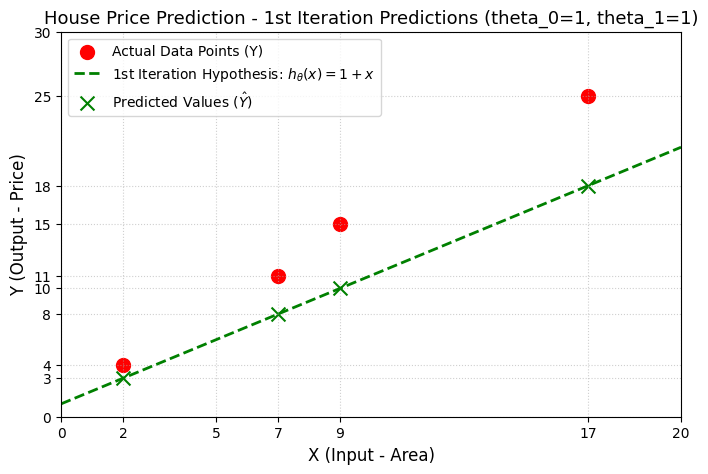

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset points
X = np.array([7, 2, 17, 9])
Y = np.array([11, 4, 25, 15])

# Create plot
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='red', marker='o', s=100, label='Actual Data Points (Y)')

# 1st Iteration Line: y = 1.0 + 1.0 * x
x_line = np.linspace(0, 20, 100)
y_line = 1.0 + 1.0 * x_line
plt.plot(x_line, y_line, color='green', linestyle='--', linewidth=2, label='1st Iteration Hypothesis: $h_\\theta(x) = 1 + x$')

# Predicted points on the line
Y_pred = 1.0 + 1.0 * X
plt.scatter(X, Y_pred, color='green', marker='x', s=100, label='Predicted Values ($\\hat{Y}$)')

# Customizing plot
plt.title('House Price Prediction - 1st Iteration Predictions (theta_0=1, theta_1=1)', fontsize=13)
plt.xlabel('X (Input - Area)', fontsize=12)
plt.ylabel('Y (Output - Price)', fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 30)
plt.xticks([0, 2, 5, 7, 9, 17, 20])
plt.yticks([0, 3, 4, 8, 10, 11, 15, 18, 25, 30])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Calculating parameter updates using Gradient Descent

Now we will update $\theta_0$ and $\theta_1$ using our Gradient Descent update equations with a learning rate $\alpha = 0.01$.

#### 1. Parameter Update for $\theta_0$:

$$ \theta_0 \leftarrow \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) $$

$$ \Rightarrow \theta_0 \leftarrow 1 - 0.01 \times \frac{1}{4} \left[ (8 - 11) + (3 - 4) + (18 - 25) + (10 - 15) \right] $$

$$ \Rightarrow \theta_0 \leftarrow 1 - 0.01 \times \frac{1}{4} \left[ -3 + (-1) + (-7) + (-5) \right] $$

$$ \Rightarrow \theta_0 \leftarrow 1 - 0.01 \times \frac{1}{4} \times (-16) $$

$$ \Rightarrow \theta_0 \leftarrow 1 - 0.01 \times (-4) $$

$$ \Rightarrow \theta_0 \leftarrow 1.04 \quad \text{(New)} $$

--- 

#### 2. Parameter Update for $\theta_1$:

$$ \theta_1 \leftarrow \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)} $$

$$ \Rightarrow \theta_1 \leftarrow 1 - 0.01 \times \frac{1}{4} \left[ (8 - 11) \times 7 + (3 - 4) \times 2 + (18 - 25) \times 17 + (10 - 15) \times 9 \right] $$

$$ \Rightarrow \theta_1 \leftarrow 1 - 0.01 \times \frac{1}{4} \left[ (-3) \times 7 + (-1) \times 2 + (-7) \times 17 + (-5) \times 9 \right] $$

$$ \Rightarrow \theta_1 \leftarrow 1 - 0.01 \times \frac{1}{4} \left[ -21 - 2 - 119 - 45 \right] $$

$$ \Rightarrow \theta_1 \leftarrow 1 - 0.01 \times \frac{1}{4} \times (-187) $$

$$ \Rightarrow \theta_1 \leftarrow 1 - 0.01 \times (-46.75) $$

$$ \Rightarrow \theta_1 \leftarrow 1.4675 \approx 1.4675 \quad \text{(New)} $$

## 2nd Iteration of Gradient Descent

Now we perform the **2nd iteration** using the parameters updated from the 1st iteration:
- $\theta_0 = 1.04$
- $\theta_1 = 1.4675$

The linear hypothesis equation is:
$$ h_\theta(x) = 1.04 + 1.4675 x $$

Using our dataset, we calculate the predictions for each row:
- **1st row ($x = 7$):**
  $$ h_\theta(7) = 1.04 + 1.4675 \times 7 = 11.3125 $$
- **2nd row ($x = 2$):**
  $$ h_\theta(2) = 1.04 + 1.4675 \times 2 = 3.975 $$
- **3rd row ($x = 17$):**
  $$ h_\theta(17) = 1.04 + 1.4675 \times 17 = 25.9875 $$
- **4th row ($x = 9$):**
  $$ h_\theta(9) = 1.04 + 1.4675 \times 9 = 14.2475 $$

--- 

### Comparison Table (2nd Iteration)

Here is the table showing the predicted values for the 2nd iteration:

| $X$ | $Y$ | Predicted ($\hat{y}$) |
| :---: | :---: | :---: |
| 7 | 11 | 11.3125 |
| 2 | 4 | 3.9750 |
| 17 | 25 | 25.9875 |
| 9 | 15 | 14.2475 |

--- 

### Calculating Loss (Cost $J$) for 2nd Iteration

Using our prediction cost formula:
$$ J = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

$$ J = \frac{1}{2 \times 4} \left[ (11.3125 - 11)^2 + (3.975 - 4)^2 + (25.9875 - 25)^2 + (14.2475 - 15)^2 \right] $$

$$ J = \frac{1}{8} \left[ (0.3125)^2 + (-0.025)^2 + (0.9875)^2 + (-0.7525)^2 \right] $$

$$ J = \frac{1}{8} \left[ 0.09765625 + 0.000625 + 0.97515625 + 0.56625625 \right] $$

$$ J = \frac{1}{8} \times 1.63969375 \approx 0.20496 \approx 0.205 $$

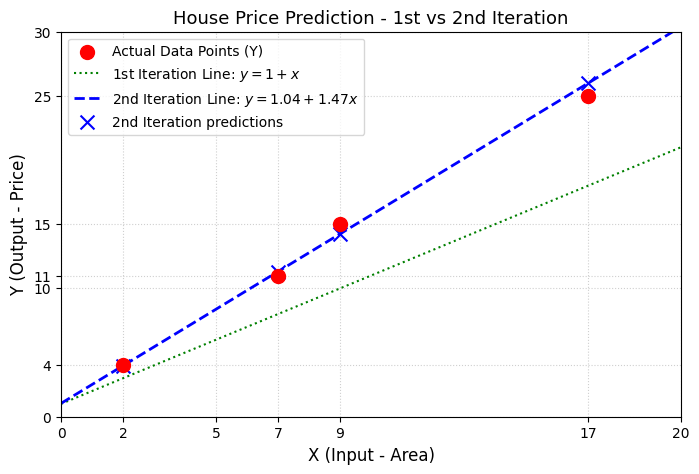

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset points
X = np.array([7, 2, 17, 9])
Y = np.array([11, 4, 25, 15])

# Create plot
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='red', marker='o', s=100, zorder=5, label='Actual Data Points (Y)')

# 1st Iteration Line (reference)
x_line = np.linspace(0, 20, 100)
y_line_1 = 1.0 + 1.0 * x_line
plt.plot(x_line, y_line_1, color='green', linestyle=':', linewidth=1.5, label='1st Iteration Line: $y = 1 + x$')

# 2nd Iteration Line: y = 1.04 + 1.4675 * x
y_line_2 = 1.04 + 1.4675 * x_line
plt.plot(x_line, y_line_2, color='blue', linestyle='--', linewidth=2, label='2nd Iteration Line: $y = 1.04 + 1.47x$')

# Predicted points for the 2nd iteration on the line
Y_pred_2 = 1.04 + 1.4675 * X
plt.scatter(X, Y_pred_2, color='blue', marker='x', s=100, zorder=4, label='2nd Iteration predictions')

# Formatting
plt.title('House Price Prediction - 1st vs 2nd Iteration', fontsize=13)
plt.xlabel('X (Input - Area)', fontsize=12)
plt.ylabel('Y (Output - Price)', fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 30)
plt.xticks([0, 2, 5, 7, 9, 17, 20])
plt.yticks([0, 4, 10, 11, 15, 25, 30])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Calculating parameter updates for the 3rd iteration

Now we calculate the updates to find the parameters for the next iteration:

#### 1. Parameter Update for $\theta_0$:
$$ \theta_0 \leftarrow \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) $$

$$ \Rightarrow \theta_0 \leftarrow 1.04 - 0.01 \times \frac{1}{4} \left[ (11.3125 - 11) + (3.975 - 4) + (25.9875 - 25) + (14.2475 - 15) \right] $$

$$ \Rightarrow \theta_0 \leftarrow 1.04 - 0.01 \times \frac{1}{4} \left[ 0.3125 + (-0.025) + 0.9875 + (-0.7525) \right] $$

$$ \Rightarrow \theta_0 \leftarrow 1.04 - 0.01 \times \frac{1}{4} \times 0.5225 $$

$$ \Rightarrow \theta_0 \leftarrow 1.04 - 0.01 \times 0.130625 $$

$$ \Rightarrow \theta_0 \leftarrow 1.0387 \quad \text{(New)} $$

--- 

#### 2. Parameter Update for $\theta_1$:
$$ \theta_1 \leftarrow \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)} $$

$$ \Rightarrow \theta_1 \leftarrow 1.4675 - 0.01 \times \frac{1}{4} \left[ 0.3125 \times 7 + (-0.025) \times 2 + 0.9875 \times 17 + (-0.7525) \times 9 \right] $$

$$ \Rightarrow \theta_1 \leftarrow 1.4675 - 0.01 \times \frac{1}{4} \left[ 2.1875 - 0.05 + 16.7875 - 6.7725 \right] $$

$$ \Rightarrow \theta_1 \leftarrow 1.4675 - 0.01 \times \frac{1}{4} \times 12.1525 $$

$$ \Rightarrow \theta_1 \leftarrow 1.4675 - 0.01 \times 3.038125 $$

$$ \Rightarrow \theta_1 \leftarrow 1.4371 \quad \text{(New)} $$

## 3rd Iteration of Gradient Descent

Now we perform the **3rd iteration** using the parameters updated from the 2nd iteration:
- $\theta_0 = 1.0387$
- $\theta_1 = 1.4371$

The linear hypothesis equation is:
$$ h_\theta(x) = 1.0387 + 1.4371 x $$

Using our dataset, we calculate the predictions for each row:
- **1st row ($x = 7$):**
  $$ h_\theta(7) = 1.0387 + 1.4371 \times 7 = 11.0984 $$
- **2nd row ($x = 2$):**
  $$ h_\theta(2) = 1.0387 + 1.4371 \times 2 = 3.9129 $$
- **3rd row ($x = 17$):**
  $$ h_\theta(17) = 1.0387 + 1.4371 \times 17 = 25.4694 $$
- **4th row ($x = 9$):**
  $$ h_\theta(9) = 1.0387 + 1.4371 \times 9 = 13.9726 $$

--- 

### Comparison Table (3rd Iteration)

Here is the table showing the predicted values for the 3rd iteration:

| $X$ | $Y$ | Predicted ($\hat{y}$) |
| :---: | :---: | :---: |
| 7 | 11 | 11.0984 |
| 2 | 4 | 3.9129 |
| 17 | 25 | 25.4694 |
| 9 | 15 | 13.9726 |

--- 

### Calculating Loss (Cost $J$) for 3rd Iteration

Using our prediction cost formula:
$$ J = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$

$$ J = \frac{1}{2 \times 4} \left[ (11.0984 - 11)^2 + (3.9129 - 4)^2 + (25.4694 - 25)^2 + (13.9726 - 15)^2 \right] $$

$$ J = \frac{1}{8} \left[ (0.0984)^2 + (-0.0871)^2 + (0.4694)^2 + (-1.0274)^2 \right] $$

$$ J = \frac{1}{8} \left[ 0.00968256 + 0.00758641 + 0.22033636 + 1.05555076 \right] $$

$$ J = \frac{1}{8} \times 1.29315609 \approx 0.16164 \approx 0.162 $$

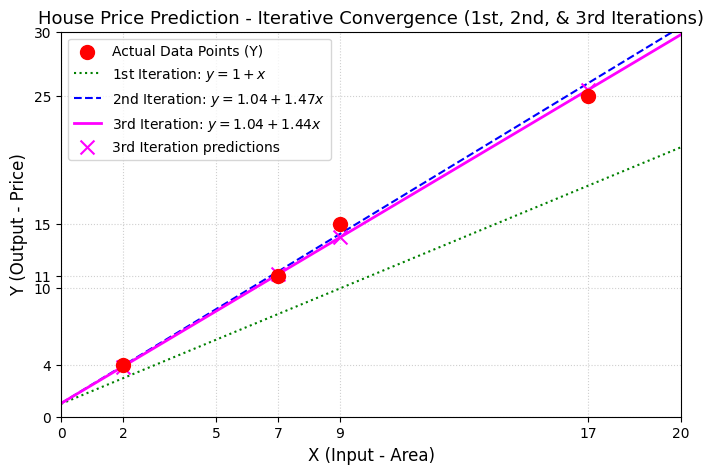

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset points
X = np.array([7, 2, 17, 9])
Y = np.array([11, 4, 25, 15])

# Create plot
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='red', marker='o', s=100, zorder=5, label='Actual Data Points (Y)')

# 1st Iteration Line
x_line = np.linspace(0, 20, 100)
y_line_1 = 1.0 + 1.0 * x_line
plt.plot(x_line, y_line_1, color='green', linestyle=':', linewidth=1.5, label='1st Iteration: $y = 1 + x$')

# 2nd Iteration Line
y_line_2 = 1.04 + 1.4675 * x_line
plt.plot(x_line, y_line_2, color='blue', linestyle='--', linewidth=1.5, label='2nd Iteration: $y = 1.04 + 1.47x$')

# 3rd Iteration Line: y = 1.0387 + 1.4371 * x
y_line_3 = 1.0387 + 1.4371 * x_line
plt.plot(x_line, y_line_3, color='magenta', linestyle='-', linewidth=2, label='3rd Iteration: $y = 1.04 + 1.44x$')

# Predicted points for the 3rd iteration on the line
Y_pred_3 = 1.0387 + 1.4371 * X
plt.scatter(X, Y_pred_3, color='magenta', marker='x', s=100, zorder=4, label='3rd Iteration predictions')

# Formatting
plt.title('House Price Prediction - Iterative Convergence (1st, 2nd, & 3rd Iterations)', fontsize=13)
plt.xlabel('X (Input - Area)', fontsize=12)
plt.ylabel('Y (Output - Price)', fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 30)
plt.xticks([0, 2, 5, 7, 9, 17, 20])
plt.yticks([0, 4, 10, 11, 15, 25, 30])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

This is how the iterations will continue, automatically updating $\theta_0$ and $\theta_1$ step-by-step, until the Mean Squared Error (MSE) cost function is minimized and the regression line reaches its best possible fit (global minima).

### Summary of Loss Reduction

If we observe the cost value ($J$) across the iterations, we can see it decreasing gradually:
- **Starting Point** (Initial Parameters $\theta_0=1, \theta_1=1$): **$J = 10.5$**
- **1st Update** (Updated Parameters $\theta_0=1.04, \theta_1=1.4675$): **$J \approx 0.205$**
- **2nd Update** (Updated Parameters $\theta_0=1.0387, \theta_1=1.4371$): **$J \approx 0.162$**

This demonstrates that Gradient Descent is successfully minimizing the error at each step, moving the hypothesis line closer to the actual data points.